In [ ]:
import pandas as pd

# Import the data
dataset = pd.read_csv("C:/Users/HP/OneDrive/Documents/Codes/Projects/Pulse/ai/ml/training/notebooks/synthetic_mental_health_dataset.csv")
dataset.head()

,sleep_hours,screen_time,exercise_minutes,daily_pending_tasks,interruptions,fatigue_level,social_hours,coffee_cups,diet_quality,weather,mood_score,stress_level
0,7.745071,3.649643,13.272466,1,5,4.179955,2.448854,1,average,snowy,9.171062,1.000000
1,6.792604,4.710963,1.785436,3,6,4.883679,1.330623,3,good,sunny,5.706491,3.558516
2,7.971533,3.415160,71.843325,4,10,4.207812,2.134120,0,poor,cloudy,10.000000,2.971450
3,9.284545,4.384077,14.596656,2,4,3.362592,1.857070,0,good,sunny,8.385038,1.000000
4,6.648770,1.212771,19.048010,3,5,6.229107,2.642980,1,poor,rainy,10.000000,1.639047


In [107]:
# Extract the necessary columns and encode diet quality
dataset = dataset[["sleep_hours", "screen_time", "stress_level", "exercise_minutes", "diet_quality", "mood_score", "fatigue_level"]]
dataset["diet_quality"] = dataset["diet_quality"].replace({
    "poor": 0,
    "average": 1,
    "good": 2
})
dataset.head()

,sleep_hours,screen_time,stress_level,exercise_minutes,diet_quality,mood_score,fatigue_level
0,7.745071,3.649643,1.000000,13.272466,1,9.171062,4.179955
1,6.792604,4.710963,3.558516,1.785436,2,5.706491,4.883679
2,7.971533,3.415160,2.971450,71.843325,0,10.000000,4.207812
3,9.284545,4.384077,1.000000,14.596656,2,8.385038,3.362592
4,6.648770,1.212771,1.639047,19.048010,0,10.000000,6.229107


In [51]:
# Split data into training + test sets
from sklearn.model_selection import train_test_split

X = dataset[["sleep_hours", "screen_time", "stress_level", "exercise_minutes", "diet_quality"]]
y = dataset[["mood_score", "fatigue_level"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67)
y_train.columns

Index(['mood_score', 'fatigue_level'], dtype='str')

In [96]:
# Import models and train them
from sklearn.ensemble import RandomForestRegressor

mood_model = RandomForestRegressor()
fatigue_model = RandomForestRegressor()

mood_model.fit(X_train, y_train["mood_score"])
fatigue_model.fit(X_train, y_train["fatigue_level"])

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [99]:
# Make predictions, test models
from sklearn.metrics import r2_score, mean_absolute_error

mood_predictions = mood_model.predict(X_test)
fatigue_predictions = fatigue_model.predict(X_test)

print(f"--- MOOD MODEL METRICS ---")
print(f"R2 SCORE : {r2_score(y_test["mood_score"], mood_predictions)}")
print(f"MAE: {mean_absolute_error(y_test["mood_score"], mood_predictions)}")
print("\n")
print(f"--- FATIGUE MODEL METRICS ---")
print(f"R2 SCORE : {r2_score(y_test["fatigue_level"], fatigue_predictions)}")
print(f"MAE: {mean_absolute_error(y_test["fatigue_level"], fatigue_predictions)}")

--- MOOD MODEL METRICS ---
R2 SCORE : 0.8980687162078969
MAE: 0.46643982987980104


--- FATIGUE MODEL METRICS ---
R2 SCORE : -0.11959490849952692
MAE: 1.6902612341386702


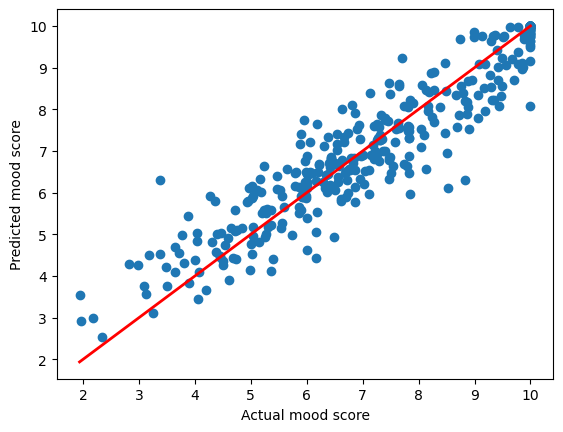

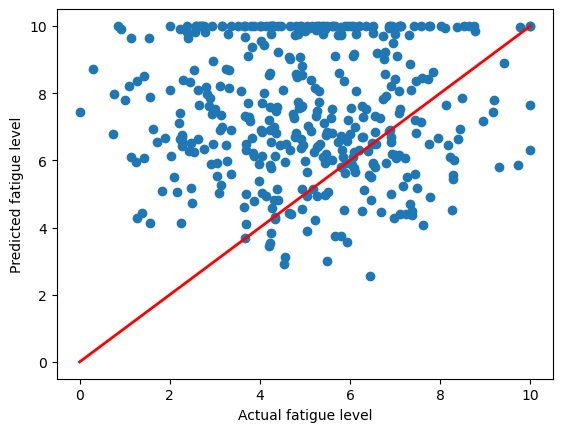

In [ ]:
# Visualization
import matplotlib.pyplot as plt

# Mood score prediction
plt.scatter(y_test["mood_score"], mood_predictions)
plt.xlabel("Actual mood score")
plt.ylabel("Predicted mood score")
plt.plot(
    [y_test["mood_score"].min(), y_test["mood_score"].max()],
    [y_test["mood_score"].min(), y_test["mood_score"].max()],
    color="red", linewidth=2
)
plt.show()

# Fatigue level prediction, pretty bad
plt.scatter(y_test["fatigue_level"], mood_predictions)
plt.xlabel("Actual fatigue level")
plt.ylabel("Predicted fatigue level")
plt.plot(
    [y_test["fatigue_level"].min(), y_test["fatigue_level"].max()],
    [y_test["fatigue_level"].min(), y_test["fatigue_level"].max()],
    color="red", linewidth=2
)
plt.show()

In [110]:
# Export the mood prediction model
import joblib
import os

joblib.dump(mood_model, "mood_predictor.pkl")
os.getcwd()

'C:\\Users\\HP'